In [72]:
from sys import displayhook
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [73]:
import pandas as pd
import numpy as np
import seaborn as sns

In [74]:
old_runsolver = pd.read_csv("storage_alice/Instance_multithread_new_default/all_outputs.csv")
new_runsolver = pd.read_csv("storage_alice/new_runsolver_default_config/default_new_runsovler340.csv")

In [75]:
display(old_runsolver.head(
))

,Unnamed: 0,Status,Runtime,Runlength,quality,seed,File
0,0,UNSAT,156.233,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...
1,1,UNSAT,320.391,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...
2,2,UNSAT,495.880,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...
3,3,UNSAT,935.100,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...
4,4,UNSAT,1012.520,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...


In [76]:
result_frame = pd.merge(old_runsolver, new_runsolver, how="inner", on="File")
display(result_frame.head())
# print(result_frame["Runtime_new"])


,Unnamed: 0_x,Status_x,Runtime_x,Runlength_x,quality_x,seed_x,File,Unnamed: 0_y,Status_y,Runtime_y,Runlength_y,quality_y,seed_y
0,0,UNSAT,156.233,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,0,UNSAT,158.555,0,0,-1
1,1,UNSAT,320.391,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,1,UNSAT,323.454,0,0,-1
2,2,UNSAT,495.880,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,2,UNSAT,486.328,0,0,-1
3,3,UNSAT,935.100,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,3,UNSAT,921.222,0,0,-1
4,4,UNSAT,1012.520,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,4,UNSAT,991.593,0,0,-1


In [83]:
# print(result_frame["Status_x"] == result_frame["Status_y"])
lis = result_frame["Status_x"] == result_frame["Status_y"]
for idx, i in enumerate(lis):
    if i is False:
        print("--------------")
        print("False found")
        print(result_frame.loc[idx, ["Status_x", "Status_y"]])

--------------
False found
Status_x    EXTERNALKILL
Status_y           UNSAT
Name: 28, dtype: object
--------------
False found
Status_x    EXTERNALKILL
Status_y         SUCCESS
Name: 57, dtype: object
--------------
False found
Status_x    EXTERNALKILL
Status_y         SUCCESS
Name: 103, dtype: object
--------------
False found
Status_x    EXTERNALKILL
Status_y         SUCCESS
Name: 104, dtype: object
--------------
False found
Status_x    EXTERNALKILL
Status_y         SUCCESS
Name: 126, dtype: object
--------------
False found
Status_x    EXTERNALKILL
Status_y         SUCCESS
Name: 127, dtype: object
--------------
False found
Status_x    EXTERNALKILL
Status_y         SUCCESS
Name: 140, dtype: object
--------------
False found
Status_x    EXTERNALKILL
Status_y         SUCCESS
Name: 159, dtype: object


In [65]:
print(result_frame["Status_x"].value_counts())
print(result_frame["Status_y"].value_counts())

Status_x
SUCCESS         120
UNSAT            45
TIMEOUT          11
EXTERNALKILL      8
Name: count, dtype: int64
Status_y
SUCCESS    127
UNSAT       46
TIMEOUT     11
Name: count, dtype: int64


No more EXTERNALKILL with the recompiled runsolver

<Axes: xlabel='Runtime_x', ylabel='Runtime_y'>

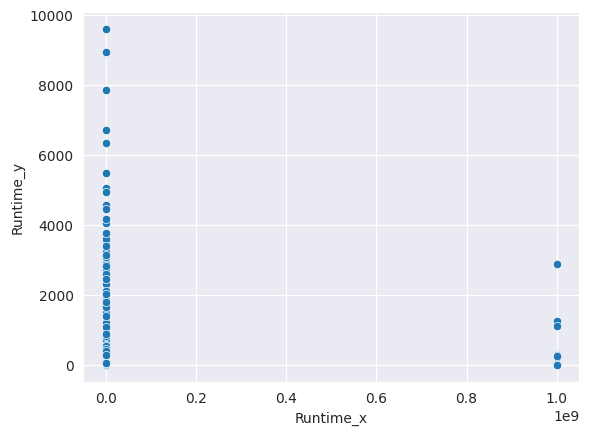

In [66]:
sns.scatterplot(data=result_frame, x="Runtime_x", y="Runtime_y")

In [67]:
result_frame.loc[(result_frame["Status_x"] == "EXTERNALKILL"), "Runtime_x"] = 9600
result_frame.loc[(result_frame["Status_y"] == "EXTERNALKILL"), "Runtime_y"] = 9600

<Axes: xlabel='Runtime_x', ylabel='Runtime_y'>

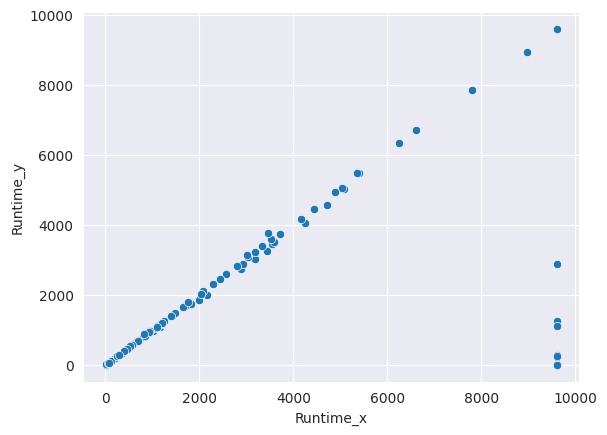

In [68]:
sns.scatterplot(data=result_frame, x="Runtime_x", y="Runtime_y")

Recompiling the runsolver fixed the externakills

In [69]:
print(result_frame.to_string())

     Unnamed: 0_x      Status_x   Runtime_x  Runlength_x  quality_x  seed_x                                                      File  Unnamed: 0_y Status_y   Runtime_y  Runlength_y  quality_y  seed_y
0               0         UNSAT   156.23300            0          0      -1     aclib2/instances/mip/data/SDPdMLPa-MIPVerify/mip_5.lp             0    UNSAT   158.55500            0          0      -1
1               1         UNSAT   320.39100            0          0      -1     aclib2/instances/mip/data/SDPdMLPa-MIPVerify/mip_4.lp             1    UNSAT   323.45400            0          0      -1
2               2         UNSAT   495.88000            0          0      -1    aclib2/instances/mip/data/SDPdMLPa-MIPVerify/mip_18.lp             2    UNSAT   486.32800            0          0      -1
3               3         UNSAT   935.10000            0          0      -1    aclib2/instances/mip/data/SDPdMLPa-MIPVerify/mip_11.lp             3    UNSAT   921.22200            0          0    

# Externakill dataset

Not necessary, turns out there was a mistake in the code and rebuilding the runsolver fixed it.

In [70]:
# new_df = new_runsolver.loc[(new_runsolver["Status"] == "EXTERNALKILL")]
# display(new_df)
# (new_runsolver["Status"] == "EXTERNALKILL")
# new_runsolver["Status"]

,Unnamed: 0,Status,Runtime,Runlength,quality,seed,File


0        UNSAT
1        UNSAT
2        UNSAT
3        UNSAT
4        UNSAT
        ...   
179    SUCCESS
180    SUCCESS
181    TIMEOUT
182    SUCCESS
183    TIMEOUT
Name: Status, Length: 184, dtype: object

In [ ]:
# import shutil
# import os
#
# from pathlib import Path
# from dotenv import load_dotenv
# load_dotenv()
#
# new_loc = f"./dataset_externakill/instances"
# Path(f"./dataset_externakill/instances").mkdir(parents=True, exist_ok=True)
#
#
# base_loc = os.getenv("INSTANCE_DIR")
# print(base_loc)
#
# for file_name in small_dataset["File"]:
#     numba = os.path.basename(file_name)[:-4]
#     # print(numba)
#     shutil.copyfile(f"{base_loc}/mip_{numba}.lp", f"{new_loc}/mip_{numba}.lp")